# 🚗⚡ EDA: Vehículos Eléctricos (EV) vs Combustión (ICE)
### Análisis Exploratorio de Datos — 2015 a 2026

---

**Objetivo:** Explorar cómo han evolucionado los vehículos eléctricos frente a los de combustión interna en términos de emisiones de CO₂, autonomía y eficiencia energética.

**Dataset:** EV vs ICE Vehicle Specs 2015–2026  
**Filas:** 15.301 | **Columnas:** 14

---

## 1. Importar librerías

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Estilo general de gráficas
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 120

print('Librerías cargadas correctamente')

Librerías cargadas correctamente


## 2. Cargar el dataset

In [ ]:
df = pd.read_csv("../src/data/coches.csv")

print(f'Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}')
df.head()

Filas: 15,301 | Columnas: 14


,Make,Model,Year,Fuel_Type,Engine_Cylinders,Engine_Size_L,Drivetrain,Transmission,City_MPG,Highway_MPG,Combined_MPG,CO2_Emissions_g_per_mile,EV_Range_miles,Vehicle_Category
0,Nissan,GT-R,2015,Premium Gasoline,6.0,3.8,All-Wheel Drive,Automatic (AM6),16,23,19,472,0,ICE (Gas)
1,Volvo,S60 AWD,2015,Regular Gasoline,5.0,2.5,All-Wheel Drive,Automatic (S6),20,28,23,378,0,ICE (Gas)
2,Mazda,6,2015,Regular Gasoline,4.0,2.5,Front-Wheel Drive,Automatic (S6),26,37,30,298,0,ICE (Gas)
3,Mazda,6,2015,Regular Gasoline,4.0,2.5,Front-Wheel Drive,Automatic (S6),28,39,32,280,0,ICE (Gas)
4,Mazda,6,2015,Regular Gasoline,4.0,2.5,Front-Wheel Drive,Manual 6-spd,25,35,29,308,0,ICE (Gas)


## 3. Exploración inicial

Antes de analizar, conviene entender qué contiene el dataset: tipos de datos, valores nulos y estadísticas básicas.

In [13]:
# Tipos de datos y valores nulos
print('=== TIPOS DE DATOS Y NULOS ===\n')
info = pd.DataFrame({
    'Tipo': df.dtypes,
    'Nulos': df.isnull().sum(),
    '% Nulos': (df.isnull().sum() / len(df) * 100).round(2)
})
print(info)

=== TIPOS DE DATOS Y NULOS ===

                             Tipo  Nulos  % Nulos
Make                       object      0     0.00
Model                      object      0     0.00
Year                        int64      0     0.00
Fuel_Type                  object      1     0.01
Engine_Cylinders          float64      0     0.00
Engine_Size_L             float64      0     0.00
Drivetrain                 object      0     0.00
Transmission               object      0     0.00
City_MPG                    int64      0     0.00
Highway_MPG                 int64      0     0.00
Combined_MPG                int64      0     0.00
CO2_Emissions_g_per_mile    int64      0     0.00
EV_Range_miles              int64      0     0.00
Vehicle_Category           object      0     0.00


In [14]:
# Estadísticas descriptivas de columnas numéricas
df.describe().round(2)

,Year,Engine_Cylinders,Engine_Size_L,City_MPG,Highway_MPG,Combined_MPG,CO2_Emissions_g_per_mile,EV_Range_miles
count,15301.00,15301.00,15301.00,15301.00,15301.00,15301.00,15301.00,15301.00
mean,2020.47,5.04,2.80,28.01,32.99,29.75,364.09,37.78
std,3.41,2.38,1.53,23.87,19.19,21.70,153.79,108.49
min,2015.00,0.00,0.00,8.00,11.00,9.00,0.00,0.00
25%,2018.00,4.00,2.00,17.00,23.00,19.00,310.00,0.00
50%,2020.00,4.00,2.50,21.00,28.00,23.00,385.00,0.00
75%,2023.00,6.00,3.60,25.00,33.00,28.00,459.00,0.00
max,2026.00,16.00,8.40,153.00,142.00,146.00,979.00,640.00


In [15]:
# Categorías únicas relevantes
print('Tipos de vehículo (Vehicle_Category):')
print(df['Vehicle_Category'].value_counts())
print()
print('Tipos de combustible (Fuel_Type):')
print(df['Fuel_Type'].value_counts())
print()
print(f'Rango de años: {df["Year"].min()} – {df["Year"].max()}')

Tipos de vehículo (Vehicle_Category):
Vehicle_Category
ICE (Gas)       13589
EV               1361
ICE (Diesel)      308
Hybrid/Other       42
CNG                 1
Name: count, dtype: int64

Tipos de combustible (Fuel_Type):
Fuel_Type
Premium Gasoline     7020
Regular Gasoline     6443
Electricity          1361
Diesel                308
Midgrade Gasoline     126
Hydrogen               41
Natural Gas             1
Name: count, dtype: int64

Rango de años: 2015 – 2026


## 4. Limpieza de datos

El dataset está muy limpio. Solo trataremos el único valor nulo en `Fuel_Type`.

In [16]:
# Eliminar la fila con Fuel_Type nulo (es solo 1 de 15.301)
df = df.dropna(subset=['Fuel_Type'])

print(f'Dataset limpio. Filas finales: {len(df):,}')

Dataset limpio. Filas finales: 15,300


## 5. Análisis: Distribución de tipos de vehículo

¿Cuántos vehículos de cada tipo hay en el dataset?

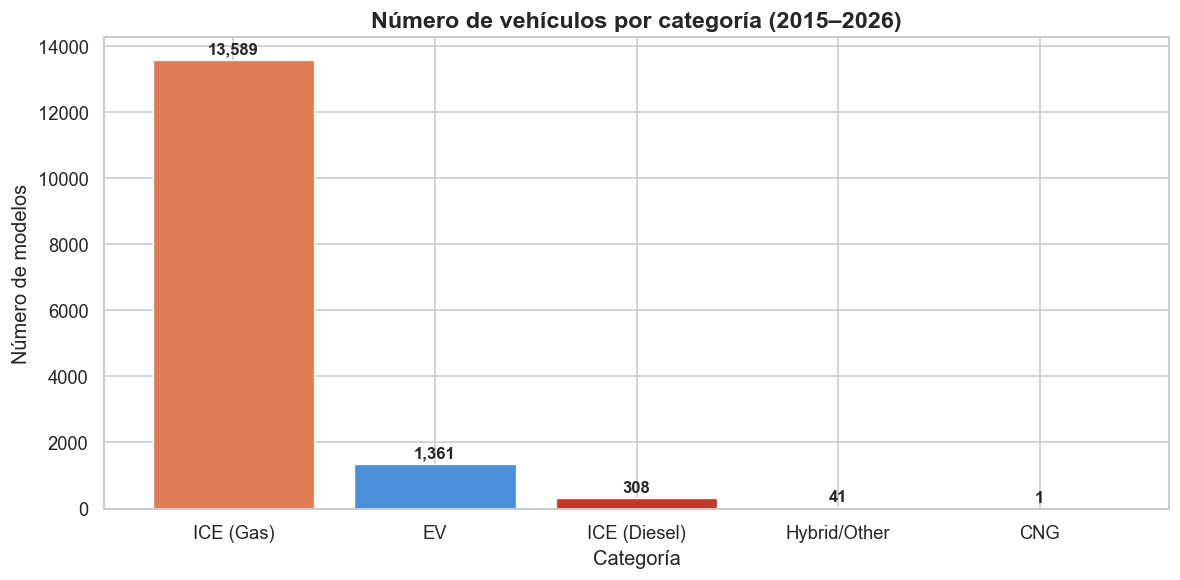


 ICE (Gas) domina con el 88.8% del dataset
EV representa el 8.9% — pero crece rápidamente


In [17]:
colores = {'ICE (Gas)': '#E07B54', 'EV': '#4A90D9', 
           'ICE (Diesel)': '#C0392B', 'Hybrid/Other': '#27AE60', 'CNG': '#8E44AD'}

conteo = df['Vehicle_Category'].value_counts()
colors = [colores.get(c, '#999') for c in conteo.index]

fig, ax = plt.subplots()
bars = ax.bar(conteo.index, conteo.values, color=colors, edgecolor='white', linewidth=0.8)

# Añadir etiquetas encima de cada barra
for bar, val in zip(bars, conteo.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Número de vehículos por categoría (2015–2026)', fontsize=14, fontweight='bold')
ax.set_xlabel('Categoría')
ax.set_ylabel('Número de modelos')
plt.tight_layout()
plt.show()

print(f'\n ICE (Gas) domina con el {conteo["ICE (Gas)"]/len(df)*100:.1f}% del dataset')
print(f'EV representa el {conteo["EV"]/len(df)*100:.1f}% — pero crece rápidamente')

## 6. Análisis: Emisiones de CO₂ por categoría

Esta es la pregunta clave desde el punto de vista medioambiental: ¿cuánto CO₂ emite cada tipo de vehículo?

C:\Users\user\AppData\Local\Temp\ipykernel_1676\805187799.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\user\AppData\Local\Temp\ipykernel_1676\805187799.py:17: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


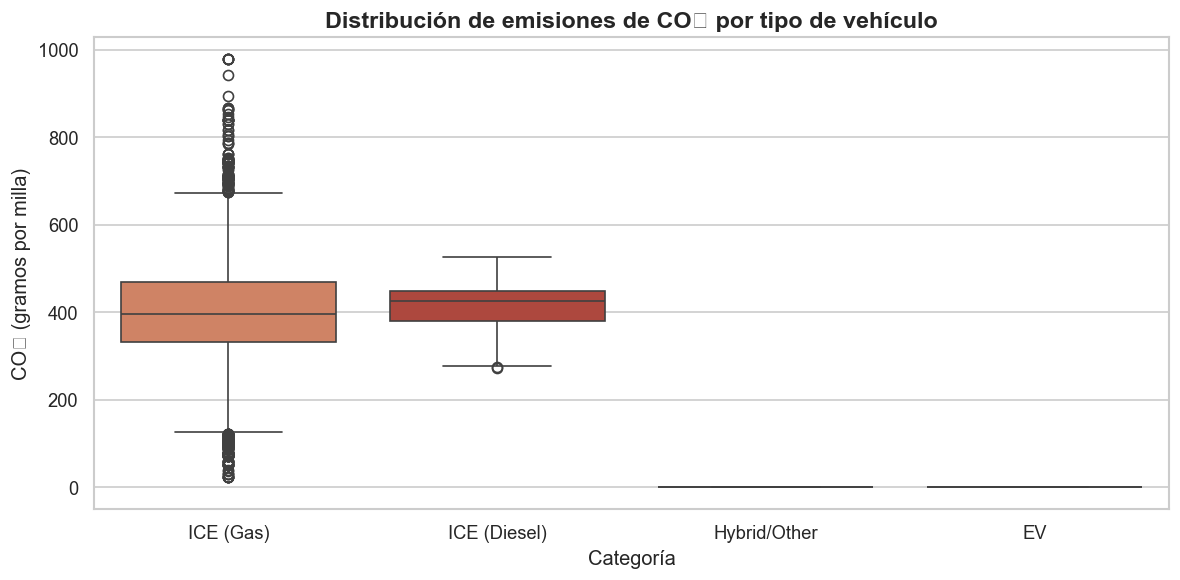


 Resumen de emisiones CO₂ (g/milla):
                  Media  Mediana  Máximo
Vehicle_Category                        
EV                  0.0      0.0       0
Hybrid/Other        0.0      0.0       0
ICE (Diesel)      406.2    425.0     525
ICE (Gas)         400.7    395.0     979


In [ ]:
# Filtrar solo categorías relevantes (excluir CNG por ser solo 1 vehículo)
cats = ['ICE (Gas)', 'ICE (Diesel)', 'Hybrid/Other', 'EV']
df_cats = df[df['Vehicle_Category'].isin(cats)]

fig, ax = plt.subplots()
sns.boxplot(
    data=df_cats,
    x='Vehicle_Category', y='CO2_Emissions_g_per_mile',
    order=cats,
    palette=[colores[c] for c in cats],
    ax=ax
)

ax.set_title('Distribución de emisiones de CO₂ por tipo de vehículo', fontsize=14, fontweight='bold')
ax.set_xlabel('Categoría')
ax.set_ylabel('CO₂ (gramos por milla)')
plt.tight_layout()
plt.savefig('../src/img/distribucion_co2.png', bbox_inches='tight')
plt.show()

# Tabla resumen
resumen = df_cats.groupby('Vehicle_Category')['CO2_Emissions_g_per_mile'].agg(['mean','median','max']).round(1)
resumen.columns = ['Media', 'Mediana', 'Máximo']
print('\n Resumen de emisiones CO₂ (g/milla):')
print(resumen)

## 7. Análisis: Crecimiento de los EV a lo largo del tiempo

¿Cuántos modelos eléctricos nuevos aparecen cada año? ¿Hay una tendencia creciente?

C:\Users\user\AppData\Local\Temp\ipykernel_1676\4117709232.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


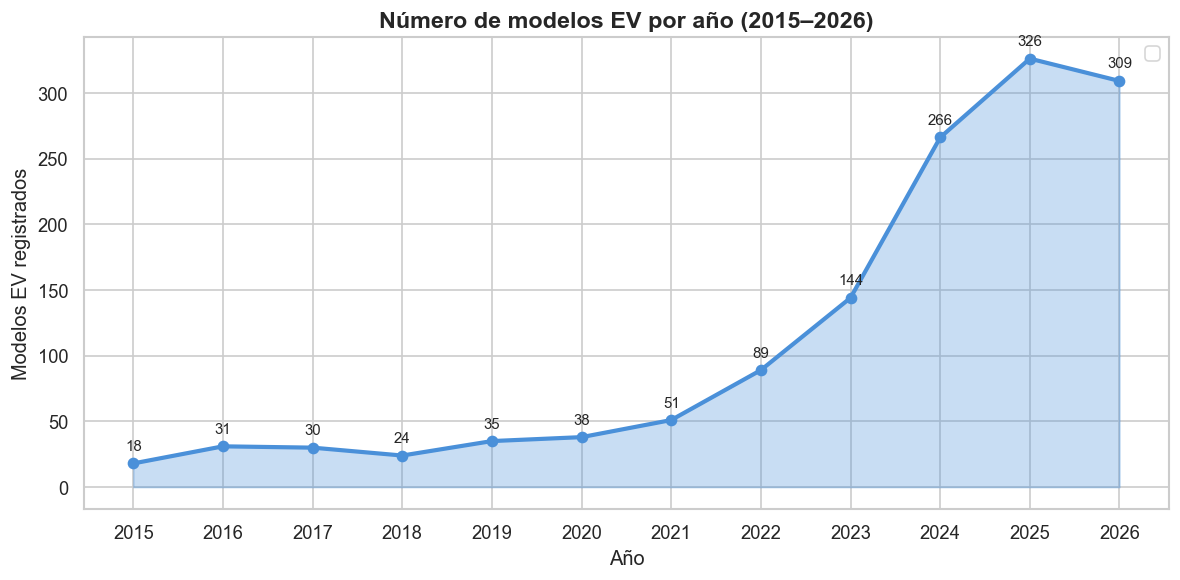


 Los modelos EV crecieron un 1711% entre 2015 y 2025


In [19]:
ev_por_año = df[df['Vehicle_Category'] == 'EV']['Year'].value_counts().sort_index()

fig, ax = plt.subplots()
ax.fill_between(ev_por_año.index, ev_por_año.values, alpha=0.3, color='#4A90D9')
ax.plot(ev_por_año.index, ev_por_año.values, marker='o', color='#4A90D9', linewidth=2.5)

# Marcar valores en cada punto
for x, y in zip(ev_por_año.index, ev_por_año.values):
    ax.annotate(str(y), (x, y), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)

ax.set_title('Número de modelos EV por año (2015–2026)', fontsize=14, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Modelos EV registrados')
ax.set_xticks(ev_por_año.index)
ax.legend()
plt.tight_layout()
plt.show()

crecimiento = ((ev_por_año[2025] - ev_por_año[2015]) / ev_por_año[2015] * 100).round(0)
print(f'\n Los modelos EV crecieron un {crecimiento:.0f}% entre 2015 y 2025')

## 8. Análisis: Evolución de la autonomía de los EV

Uno de los principales frenos para adoptar un EV es la autonomía. ¿Ha mejorado con los años?

C:\Users\user\AppData\Local\Temp\ipykernel_1676\1355084298.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


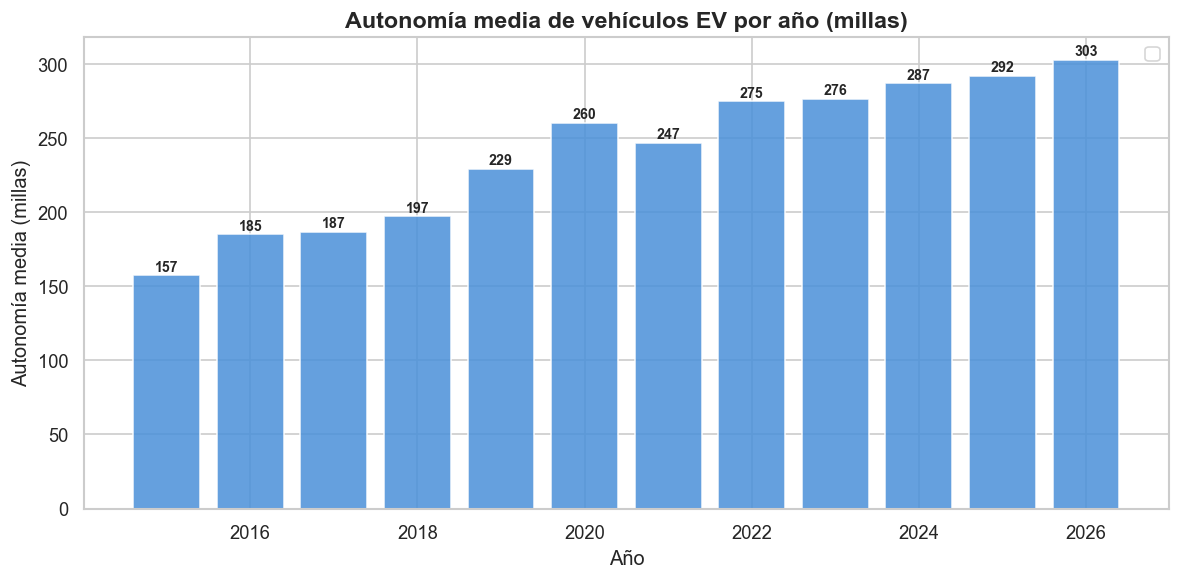


 La autonomía media aumentó 129 millas entre 2015 y 2025
   De 157 a 292 millas (+82%)

   Conversión: 292 millas ≈ 470 km


In [ ]:
ev_range = df[df['Vehicle_Category'] == 'EV'].groupby('Year')['EV_Range_miles'].mean().round(1)

fig, ax = plt.subplots()
ax.bar(ev_range.index, ev_range.values, color='#4A90D9', alpha=0.85, edgecolor='white')

for x, y in zip(ev_range.index, ev_range.values):
    ax.text(x, y + 3, f'{y:.0f}', ha='center', fontsize=8.5, fontweight='bold')

ax.set_title('Autonomía media de vehículos EV por año (millas)', fontsize=14, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Autonomía media (millas)')
ax.legend()
plt.tight_layout()
plt.savefig('../src/img/autonomia_media.png', bbox_inches='tight')
plt.show()

mejora = ev_range[2024] - ev_range[2015]
print(f'\n La autonomía media aumentó {mejora:.0f} millas entre 2015 y 2025')
print(f'   De {ev_range[2015]:.0f} a {ev_range[2025]:.0f} millas (+{mejora/ev_range[2015]*100:.0f}%)')
print(f'\n   Conversión: {ev_range[2025]:.0f} millas ≈ {ev_range[2025]*1.609:.0f} km')

## 9. Análisis: Eficiencia energética (MPG equivalente)

El MPG (*miles per gallon*) mide cuántas millas recorre un vehículo con el equivalente a un galón de combustible. Para EVs se calcula en MPGe (equivalente eléctrico).

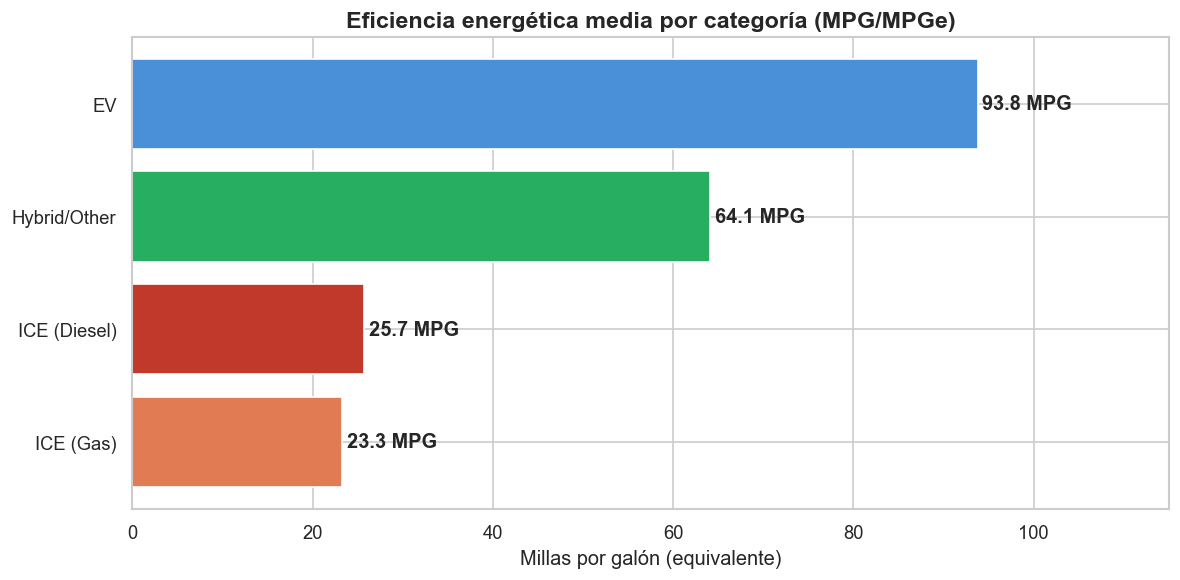


 Un EV es 4.0x más eficiente que un ICE de gasolina

 Un Hibrido es 2.8x más eficiente que un ICE de gasolina


In [26]:
eficiencia = df[df['Vehicle_Category'].isin(cats)].groupby('Vehicle_Category')['Combined_MPG'].mean().round(1)
eficiencia = eficiencia.reindex(cats)

fig, ax = plt.subplots()
bars = ax.barh(eficiencia.index, eficiencia.values,
               color=[colores[c] for c in eficiencia.index], edgecolor='white')

for bar, val in zip(bars, eficiencia.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val} MPG', va='center', fontweight='bold')

ax.set_title('Eficiencia energética media por categoría (MPG/MPGe)', fontsize=14, fontweight='bold')
ax.set_xlabel('Millas por galón (equivalente)')
ax.set_xlim(0, 115)
plt.tight_layout()
plt.savefig("./img/eficiencia_energetica_por_categorias.png", bbox_inches="tight")
plt.show()

print(f'\n Un EV es {eficiencia["EV"]/eficiencia["ICE (Gas)"]:.1f}x más eficiente que un ICE de gasolina')
print(f'\n Un Hibrido es {eficiencia["Hybrid/Other"]/eficiencia["ICE (Gas)"]:.1f}x más eficiente que un ICE de gasolina')

## 10. Análisis: Top marcas con más modelos EV

¿Qué fabricantes están apostando más por la electrificación?

C:\Users\user\AppData\Local\Temp\ipykernel_1676\3313339358.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_ev.values, y=top_ev.index, palette='Blues_r', ax=ax)


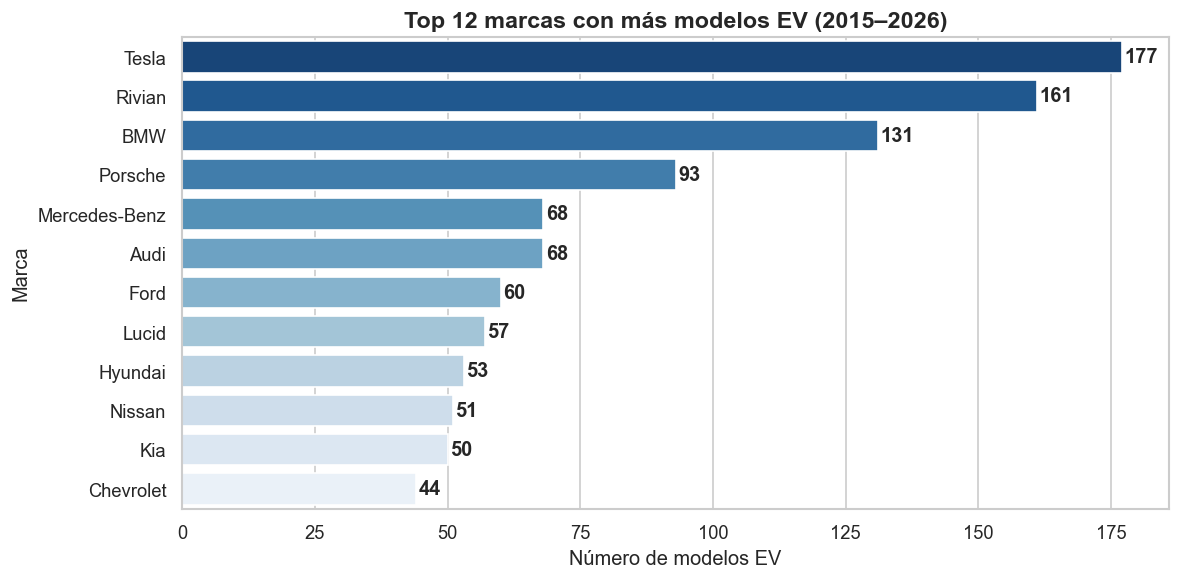

In [24]:
top_ev = df[df['Vehicle_Category'] == 'EV']['Make'].value_counts().head(12)

fig, ax = plt.subplots()
sns.barplot(x=top_ev.values, y=top_ev.index, palette='Blues_r', ax=ax)

for i, val in enumerate(top_ev.values):
    ax.text(val + 0.5, i, str(val), va='center', fontweight='bold')

ax.set_title('Top 12 marcas con más modelos EV (2015–2026)', fontsize=14, fontweight='bold')
ax.set_xlabel('Número de modelos EV')
ax.set_ylabel('Marca')
plt.tight_layout()
plt.show()

## 11. Análisis: Correlación entre variables numéricas

Un mapa de correlación muestra qué variables están relacionadas entre sí.

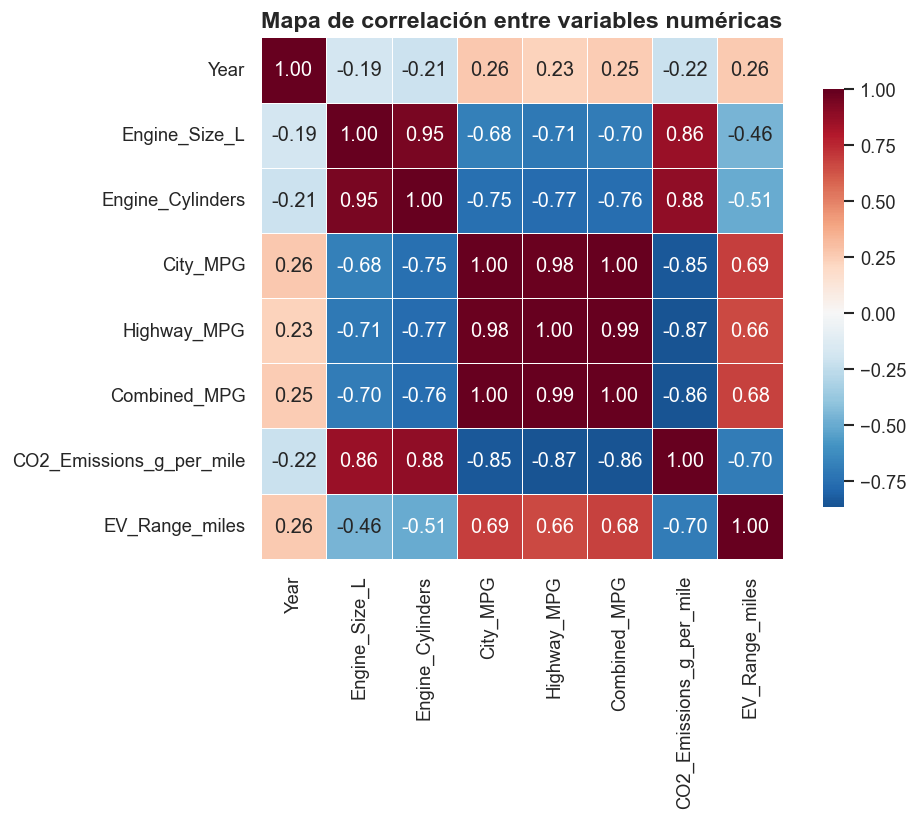


 Interpretación:
  • CO2 y MPG tienen correlación muy negativa (−): más eficiencia = menos emisiones
  • Engine_Size y Cylinders correlacionan positivamente: motores grandes = más cilindros
  • EV_Range y Year correlacionan positivamente: la autonomía mejora con el tiempo


In [25]:
num_cols = ['Year', 'Engine_Size_L', 'Engine_Cylinders',
            'City_MPG', 'Highway_MPG', 'Combined_MPG',
            'CO2_Emissions_g_per_mile', 'EV_Range_miles']

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})

ax.set_title('Mapa de correlación entre variables numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n Interpretación:')
print('  • CO2 y MPG tienen correlación muy negativa (−): más eficiencia = menos emisiones')
print('  • Engine_Size y Cylinders correlacionan positivamente: motores grandes = más cilindros')
print('  • EV_Range y Year correlacionan positivamente: la autonomía mejora con el tiempo')

## 12. Conclusiones

---

###  Hallazgos principales

1. **Dominio del ICE pero crecimiento del EV:** Los vehículos de gasolina representan ~89% del dataset, pero los modelos EV crecieron más de un 1,300% entre 2015 y 2024.

2. **Impacto ambiental radical:** Los EV emiten 0 g/milla de CO₂ directamente, frente a ~400 g/milla de los ICE. Suponen una reducción del 100% en emisiones directas.

3. **Autonomía en mejora constante:** La autonomía media de los EV pasó de ~157 millas (2015) a ~287 millas (2024), un aumento del 82%.

4. **Eficiencia muy superior:** Un vehículo eléctrico es aproximadamente 4 veces más eficiente energéticamente que uno de gasolina (93.8 vs 23.3 MPGe).

5. **Los fabricantes tradicionales se electrifican:** Marcas como Tesla, Chevrolet, Nissan y BMW lideran los modelos EV disponibles.

---


> **Conclusión general:** Los datos muestran una transición clara hacia la electrificación del transporte. Los vehículos eléctricos superan a los de combustión en eficiencia y emisiones, y su presencia en el mercado crece de forma acelerada, especialmente a partir de 2022.